# 실험 결과 확인

기존 CSV를 읽어 표와 그래프로 확인하는 **분석 전용** 노트북입니다. 모델 학습, 설정 변경, 로그 저장, 최종 Test 읽기는 하지 않습니다.

VS Code에서 프로젝트의 Python 커널을 선택하고 **Run All**을 실행하세요. 로그가 갱신되면 다시 실행해야 표와 그림이 갱신됩니다. 실행 환경에 커널이 없으면 프로젝트 루트에서 `python -m pip install -r requirements-notebook.txt`를 실행하세요.

Recall은 실제 불량 중 찾아낸 비율, 재검사 대상 비율은 전체 제품 중 모델이 추가 검사 대상으로 지정한 비율입니다. OOF는 학습 내부 진단이며 미래 성능이나 실제 재검사 결과를 뜻하지 않습니다.

In [1]:
# ==========================================
# 프로젝트 경로·표시 환경·읽을 실험 폴더 지정
# - 루트 또는 reports 폴더에서 실행 가능
# - 서로 다른 실험 폴더를 자동으로 섞지 않고 명시적으로 선택
# ==========================================
from pathlib import Path
from dataclasses import replace
import json
import sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, ticker

try:
    from IPython.display import display, Markdown
except ImportError:
    # 일반 Python으로 셀을 검증하는 경우에는 표를 텍스트로 표시한다.
    display = print
    Markdown = str

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'config.json').is_file() and (p / 'src').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('프로젝트 루트 또는 reports 폴더에서 실행해 주세요.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.modeling_config import load_modeling_config
from src.threshold_policy import policy_candidates, select_policy_threshold

POLICY_DIR = ROOT / 'logs/policy_compare'
MODEL_DIR = ROOT / 'logs/quality_filtered_20261006'
TIME_DIR = ROOT / 'logs/temporal_quality_filtered_20261006_final'
ANOMALY_DIR = ROOT / 'logs/anomaly_20261006'
FEATURE_DIR = ROOT / 'logs/feature_time_20261006'
config = load_modeling_config(ROOT / 'config.json')

# 설치된 한글 폰트를 사용하고 없는 환경에서는 영어 그래프 축을 사용한다.
fonts = {font.name for font in font_manager.fontManager.ttflist}
korean_font = next((name for name in ['Malgun Gothic', 'AppleGothic', 'NanumGothic'] if name in fonts), None)
if korean_font:
    plt.rcParams['font.family'] = korean_font
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 20)
print('프로젝트:', ROOT)
print('현재 설정 정책:', config.threshold_policy)

프로젝트: d:\workspace\secom-waferguard
현재 설정 정책: ThresholdPolicy(min_recall=0.9, max_reinspection_ratio=0.2, selection_rule='min_reinspection', on_infeasible='report_only')


## 1. 로그 출처와 실행 상태

파일 경로·수정 시각을 먼저 확인합니다. 수정 시각은 실행 버전의 일치를 보장하지 않습니다. 현재 설정과 과거 실행 설정을 구분하고, 정책 미충족으로 생략된 시간 검증 파일은 현재 결과로 표시하지 않습니다.

In [2]:
# ==========================================
# 명시한 로그만 읽고 누락된 파일은 미생성으로 표시
# - threshold의 반올림 없는 값을 유지
# - Test 파일 탐색이나 학습은 하지 않음
# ==========================================
def read_log(path):
    if not path.is_file():
        print('미생성 파일:', path.relative_to(ROOT))
        return None
    return pd.read_csv(path, float_precision='round_trip')

sources = {
    'OOF 후보': POLICY_DIR / 'threshold_compare.csv',
    '모델 CV': MODEL_DIR / 'model_compare.csv',
    '특징 CV': MODEL_DIR / 'feature_compare.csv',
    '과거 시간 검증': MODEL_DIR / 'time_validation.csv',
    '시간순 내부 검증': TIME_DIR / 'fold_results.csv',
    '시간순 정책 결과': TIME_DIR / 'policy_selection.csv',
    '이상 탐지 요약': ANOMALY_DIR / 'summary.csv',
    '이상 탐지 정책': ANOMALY_DIR / 'policy_selection.csv',
    '시간순 센서 축소': FEATURE_DIR / 'summary.csv',
}
inventory = pd.DataFrame([{'구분': name, '경로': str(path.relative_to(ROOT)),
    '존재': path.is_file(), '수정 시각': pd.Timestamp(path.stat().st_mtime, unit='s').tz_localize('UTC').tz_convert('Asia/Seoul') if path.is_file() else pd.NaT}
    for name, path in sources.items()])
display(inventory)
state_path = POLICY_DIR / 'execution.json'
state = json.loads(state_path.read_text(encoding='utf-8')) if state_path.is_file() else {}
display(pd.DataFrame([{'실행 상태': state.get('status', '기록 없음'),
    '실행 당시 정책': state.get('threshold_policy'),
    '정책 판단': state.get('policy_status'), '선택 threshold': state.get('threshold'),
    '시간 검증 상태': state.get('time_validation_status')}]))
raw_candidates = read_log(sources['OOF 후보'])
candidates = policy_candidates(raw_candidates, config.threshold_policy) if raw_candidates is not None else None
if raw_candidates is not None:
    provenance = [name for name in ['dataset_id', 'experiment', 'training_protocol_id', 'oof_score_method', 'threshold_use'] if name in raw_candidates]
    display(raw_candidates[provenance].drop_duplicates())
    print('아래 정책 판단은 현재 config.json을 기존 OOF 후보에 적용한 탐색 결과입니다.')
    if not state.get('oof_ready') or state.get('status') != 'completed':
        print('주의: 성공한 실행 기록이 없습니다. 아래 표는 참고용이며 후속 평가의 근거로 사용하지 마세요.')

,구분,경로,존재,수정 시각
0,OOF 후보,logs\policy_compare\threshold_compare.csv,True,2026-10-06 19:33:47.375041008+09:00
1,모델 CV,logs\quality_filtered_20261006\model_compare.csv,True,2026-10-06 12:02:03.227728605+09:00
2,특징 CV,logs\quality_filtered_20261006\feature_compare...,True,2026-10-06 12:02:04.667115688+09:00
3,과거 시간 검증,logs\quality_filtered_20261006\time_validation...,True,2026-10-06 11:59:37.985087395+09:00
4,시간순 내부 검증,logs\temporal_quality_filtered_20261006_final\...,True,2026-10-06 17:17:48.487546206+09:00
5,시간순 정책 결과,logs\temporal_quality_filtered_20261006_final\...,False,NaT
6,이상 탐지 요약,logs\anomaly_20261006\summary.csv,True,2026-10-06 20:17:52.027073383+09:00
7,이상 탐지 정책,logs\anomaly_20261006\policy_selection.csv,True,2026-10-06 20:17:52.040579796+09:00
8,시간순 센서 축소,logs\feature_time_20261006\summary.csv,True,2026-10-06 20:41:13.910990715+09:00


,실행 상태,실행 당시 정책,정책 판단,선택 threshold,시간 검증 상태
0,completed,"{'min_recall': 0.8, 'max_reinspection_ratio': ...",infeasible,None,skipped_policy_infeasible


,dataset_id,experiment,training_protocol_id,oof_score_method,threshold_use
0,secom,lightgbm_all,time:7089b34af4376938c135ff1054d93b504004f74ec...,single,candidate


아래 정책 판단은 현재 config.json을 기존 OOF 후보에 적용한 탐색 결과입니다.


## 2. 목표별 threshold 후보 비교

현재 설정의 조건 충족 여부와, 재검사 상한을 지키는 후보·검출 목표를 지키는 후보를 구분합니다. 후보가 없으면 미충족으로 남기며 임의로 기준을 낮추지 않습니다. **노트북의 비교는 설정이나 실행 기록을 변경하지 않습니다.**

In [3]:
# ==========================================
# 70·80·90% 목표와 재검사 상한의 관계 확인
# - 선택 기준은 기존 소스 함수를 재사용
# - threshold 원본 값은 17자리 유효숫자로 표시
# ==========================================
RECALL_TARGETS = [0.70, 0.80, 0.90]
MAX_REINSPECTION = config.threshold_policy.max_reinspection_ratio
diagnostics = pd.DataFrame()
if candidates is not None:
    policy_rows = []
    for target in RECALL_TARGETS:
        policy = replace(config.threshold_policy, min_recall=target, max_reinspection_ratio=MAX_REINSPECTION)
        selected = select_policy_threshold(raw_candidates, policy)
        policy_rows.append({'목표 Recall': target, '재검사 상한': MAX_REINSPECTION,
                            '조건 충족': selected is not None, '선택 threshold': selected})
    display(pd.DataFrame(policy_rows))
    rows = []
    def add_candidate(label, pool, order, ascending):
        if pool.empty:
            print(label + ': 해당 후보 없음')
            return
        row = pool.sort_values(order, ascending=ascending).iloc[0]
        rows.append({'조건': label, **row[['threshold', 'recall', 'reinspection_ratio',
                     'support', 'positive_support', 'true_positive', 'false_positive', 'false_negative']].to_dict()})
    add_candidate(f'재검사 {MAX_REINSPECTION:.0%} 이하에서 최대 Recall',
                  candidates[candidates.reinspection_ratio <= MAX_REINSPECTION],
                  ['recall', 'reinspection_ratio', 'threshold'], [False, True, False])
    for target in RECALL_TARGETS:
        add_candidate(f'Recall {target:.0%} 이상에서 최소 재검사',
                      candidates[candidates.recall >= target],
                      ['reinspection_ratio', 'recall', 'threshold'], [True, False, False])
    diagnostics = pd.DataFrame(rows)
    if not diagnostics.empty:
        shown = diagnostics.rename(columns={'threshold': 'threshold 원본값', 'recall': '불량 검출률',
            'reinspection_ratio': '재검사 대상 비율', 'support': '전체 건수', 'positive_support': '실제 불량',
            'true_positive': '검출 불량 TP', 'false_positive': '추가 검사 정상 FP', 'false_negative': '놓친 불량 FN'})
        # 표시용 복사본만 문자열로 포맷해 계산용 원본을 보존한다.
        formats = {'threshold 원본값': '{:.17g}', '불량 검출률': '{:.1%}',
            '재검사 대상 비율': '{:.1%}', '전체 건수': '{:.0f}', '실제 불량': '{:.0f}',
            '검출 불량 TP': '{:.0f}', '추가 검사 정상 FP': '{:.0f}', '놓친 불량 FN': '{:.0f}'}
        for column, pattern in formats.items():
            shown[column] = shown[column].map(pattern.format)
        display(shown)

,목표 Recall,재검사 상한,조건 충족,선택 threshold
0,0.7,0.2,False,None
1,0.8,0.2,False,None
2,0.9,0.2,False,None


,조건,threshold 원본값,불량 검출률,재검사 대상 비율,전체 건수,실제 불량,검출 불량 TP,추가 검사 정상 FP,놓친 불량 FN
0,재검사 20% 이하에서 최대 Recall,6.9915696343494758e-05,47.4%,19.1%,1096,78,37,172,41
1,Recall 70% 이상에서 최소 재검사,1.0455680003827543e-05,70.5%,34.0%,1096,78,55,318,23
2,Recall 80% 이상에서 최소 재검사,2.6983148702817075e-06,83.3%,49.0%,1096,78,65,472,13
3,Recall 90% 이상에서 최소 재검사,6.2441167438054914e-07,91.0%,67.0%,1096,78,71,663,7


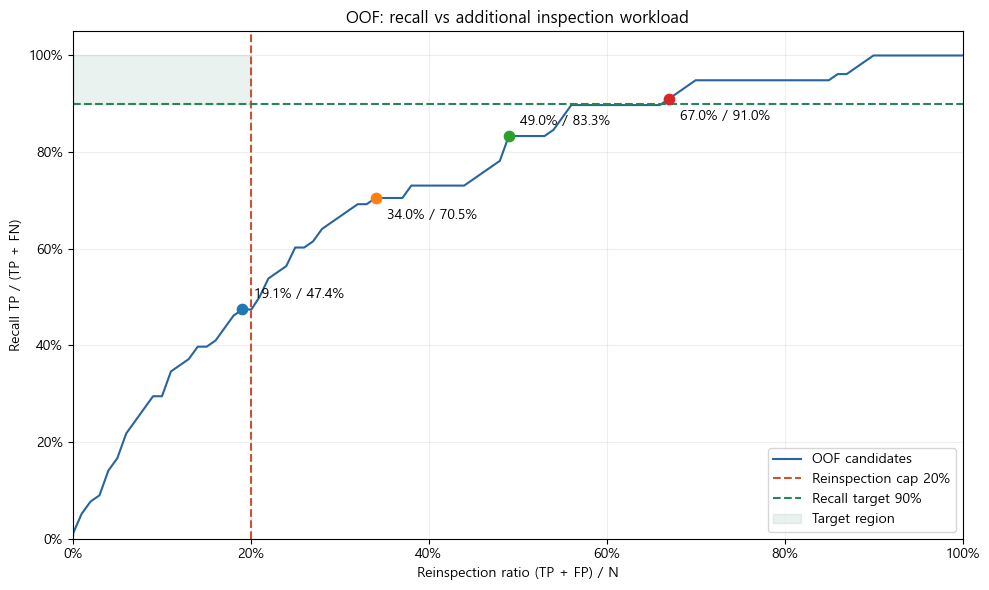

In [4]:
# 재검사 대상 범위를 넓힐 때 불량 검출률이 어떻게 변하는지 표시한다.
if candidates is not None:
    fig, ax = plt.subplots(figsize=(10, 6))
    ordered = candidates.sort_values(['reinspection_ratio', 'recall'])
    ax.plot(ordered.reinspection_ratio, ordered.recall, color='#2864a0', label='OOF candidates')
    ax.axvline(MAX_REINSPECTION, color='#c75433', linestyle='--', label=f'Reinspection cap {MAX_REINSPECTION:.0%}')
    ax.axhline(config.threshold_policy.min_recall, color='#29835b', linestyle='--', label=f'Recall target {config.threshold_policy.min_recall:.0%}')
    ax.fill_between([0, MAX_REINSPECTION], config.threshold_policy.min_recall, 1, color='#29835b', alpha=0.10, label='Target region')
    for index, row in diagnostics.iterrows():
        ax.scatter(row.reinspection_ratio, row.recall, s=55, zorder=3)
        ax.annotate(f'{row.reinspection_ratio:.1%} / {row.recall:.1%}',
                    (row.reinspection_ratio, row.recall), xytext=(8, -15 if index % 2 else 8), textcoords='offset points')
    ax.set(xlim=(0, 1), ylim=(0, 1.05), xlabel='Reinspection ratio (TP + FP) / N',
           ylabel='Recall TP / (TP + FN)', title='OOF: recall vs additional inspection workload')
    ax.xaxis.set_major_formatter(ticker.PercentFormatter(1))
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(1))
    ax.grid(alpha=0.2)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

## 3. threshold별 미검·추가 검사 건수

문턱을 낮출수록 의심 대상이 넓어집니다. FP는 불량으로 확정되거나 폐기된 정상 제품 수가 아니라, **추가 검사 대상으로 지정한 정상 제품 수**입니다. threshold는 매우 작을 수 있어 로그 축을 사용합니다.

로그 축에서 제외한 threshold=0 후보: 0


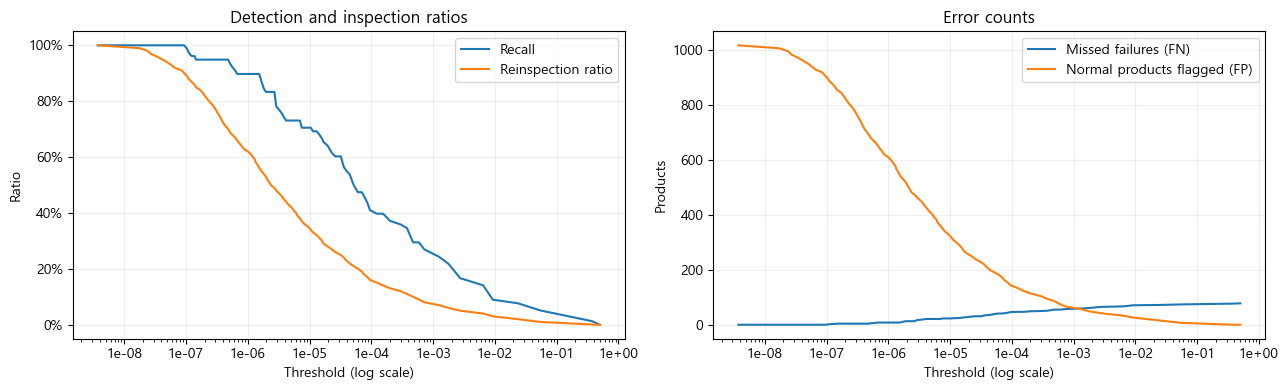

In [5]:
if candidates is not None:
    # 로그 축에 표현할 수 없는 threshold 0은 그림에서만 제외한다.
    curve = candidates[candidates.threshold > 0].sort_values('threshold')
    print('로그 축에서 제외한 threshold=0 후보:', int((candidates.threshold == 0).sum()))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(curve.threshold, curve.recall, label='Recall')
    axes[0].plot(curve.threshold, curve.reinspection_ratio, label='Reinspection ratio')
    axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(1))
    axes[0].set(title='Detection and inspection ratios', ylabel='Ratio')
    axes[1].plot(curve.threshold, curve.false_negative, label='Missed failures (FN)')
    axes[1].plot(curve.threshold, curve.false_positive, label='Normal products flagged (FP)')
    axes[1].set(title='Error counts', ylabel='Products')
    for ax in axes:
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda value, position: f'{value:.0e}'))
        ax.set_xlabel('Threshold (log scale)')
        ax.grid(alpha=0.2)
        ax.legend()
    plt.tight_layout()
    plt.show()

## 4. 모델·특징 선택 비교

AP는 threshold와 무관한 순위 평가 지표입니다. 막대는 CV 평균, 오차 막대는 fold 지표의 표준편차이며 신뢰구간은 아닙니다. 시간순 학습 데이터 내부의 계층 CV 결과이지 미래 시간 구간 성능이 아닙니다.

### 모델 CV

,model_name,train_samples,average_precision_mean,average_precision_std,recall_mean,precision_mean,threshold,training_protocol_id
0,lightgbm,1096,0.242390,0.066481,0.002667,0.040000,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...
1,lightgbm_scale_pos_weight,1096,0.237387,0.069236,0.015333,0.173333,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...
2,random_forest,1096,0.232360,0.059039,0.002500,0.013333,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...
3,rbf_svm,1096,0.171574,0.036050,0.000000,0.000000,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...
4,logistic_regression_l1,1096,0.168978,0.049337,0.163667,0.183568,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...
5,logistic_regression_l1_balanced,1096,0.168828,0.048894,0.251000,0.150216,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...


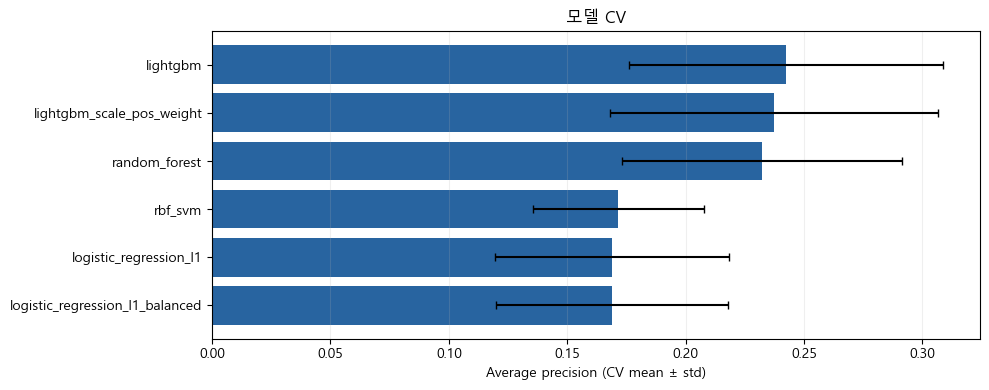

### 특징 CV

,experiment,selected_feature_count_mean,average_precision_mean,average_precision_std,recall_mean,precision_mean,threshold,training_protocol_id
0,lightgbm_all,444.00,0.242390,0.066481,0.002667,0.040000,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...
1,lightgbm_top_100,100.00,0.240709,0.070945,0.018167,0.220000,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...
2,lightgbm_top_50,50.00,0.235345,0.068077,0.036333,0.288000,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...
3,lightgbm_top_30,30.00,0.211718,0.065293,0.028167,0.181333,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...
4,lightgbm_top_20,20.00,0.204238,0.078395,0.039000,0.166095,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...
5,lightgbm_top_10,10.00,0.187154,0.060342,0.043667,0.155143,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...
6,l1_balanced_l1_select,181.16,0.168905,0.048943,0.251000,0.149949,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...
7,l1_balanced_all,444.00,0.168828,0.048894,0.251000,0.150216,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...
8,l1_balanced_pca90,121.08,0.139305,0.041026,0.333500,0.119399,0.5,time:7089b34af4376938c135ff1054d93b504004f74ec...


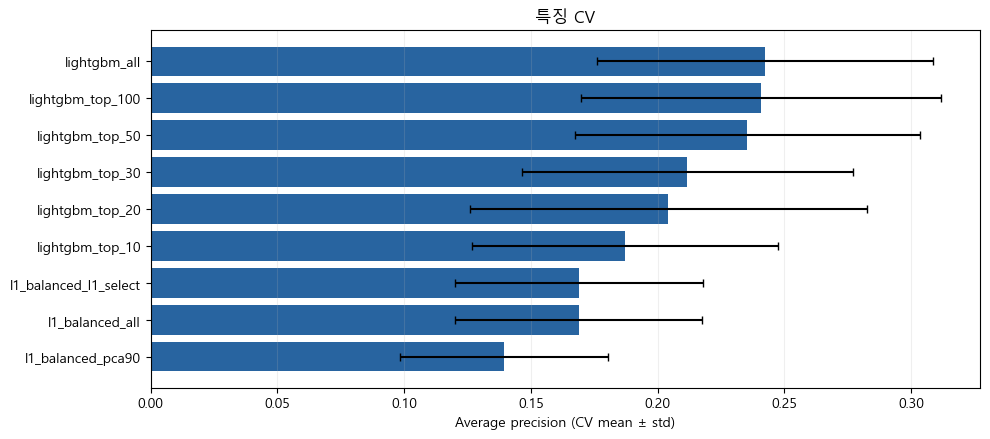

In [6]:
# 긴 품질 필터 JSON은 표에서 제외하고 주요 지표만 표시한다.
for name, name_column in [('모델 CV', 'model_name'), ('특징 CV', 'experiment')]:
    table = read_log(sources[name])
    if table is None:
        continue
    columns = [name_column, 'train_samples', 'selected_feature_count_mean', 'average_precision_mean',
               'average_precision_std', 'recall_mean', 'precision_mean', 'threshold', 'training_protocol_id']
    display(Markdown('### ' + name))
    display(table[[column for column in columns if column in table]])
    ranked = table.sort_values('average_precision_mean')
    fig, ax = plt.subplots(figsize=(10, max(4, len(ranked) * 0.5)))
    ax.barh(ranked[name_column], ranked.average_precision_mean,
            xerr=ranked.average_precision_std, color='#2864a0', capsize=3)
    ax.set(xlabel='Average precision (CV mean ± std)', title=name if korean_font else name_column + ': CV AP')
    ax.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

## 5. 미래 시간 구간에서의 성능

과거의 기본 threshold 시간 검증과 최근 정책 실행을 분리합니다. 정책 실행이 미충족·실패·생략된 경우 같은 폴더에 예전 CSV가 있어도 현재 결과로 읽지 않습니다. 내부 시간순 진단은 구간마다 다른 학습 모델·threshold이므로 최종 단일 모델 성능이 아닙니다.

과거 실행: 기본 threshold 시간 검증 — 현재 정책 실행 결과가 아닙니다.


,experiment,threshold,average_precision,recall,precision,true_positive,false_positive,false_negative,support
0,lightgbm_all,0.5,0.111008,0.0,0.0,0,0,17,235
1,l1_balanced_l1_select,0.5,0.066801,0.0,0.0,0,8,17,235


현재 정책 실행의 시간 검증 결과 없음: skipped_policy_infeasible


,outer_fold,model_name,threshold,average_precision,recall,reinspection_ratio,true_positive,false_positive,false_negative
2,1,lightgbm,2.065200e-07,0.093858,0.954545,0.982079,21,253,1
5,1,lightgbm_scale_pos_weight,1.704510e-07,0.080448,0.954545,0.971326,21,250,1
8,1,random_forest,1.033333e-01,0.074466,0.909091,0.899642,20,231,2
11,1,logistic_regression_l1_balanced,3.858666e-04,0.086423,0.863636,0.910394,19,235,3
14,2,lightgbm,5.648696e-03,0.032643,0.000000,0.007326,0,2,8
17,2,lightgbm_scale_pos_weight,1.264474e-03,0.033573,0.000000,0.054945,0,15,8
20,2,random_forest,3.000000e-02,0.129526,1.000000,0.989011,8,262,0
23,2,logistic_regression_l1_balanced,4.062724e-04,0.117628,0.875000,0.846154,7,224,1
26,3,lightgbm,2.645452e-03,0.243548,0.222222,0.025735,2,5,7
29,3,lightgbm_scale_pos_weight,5.839464e-06,0.246151,0.666667,0.404412,6,104,3


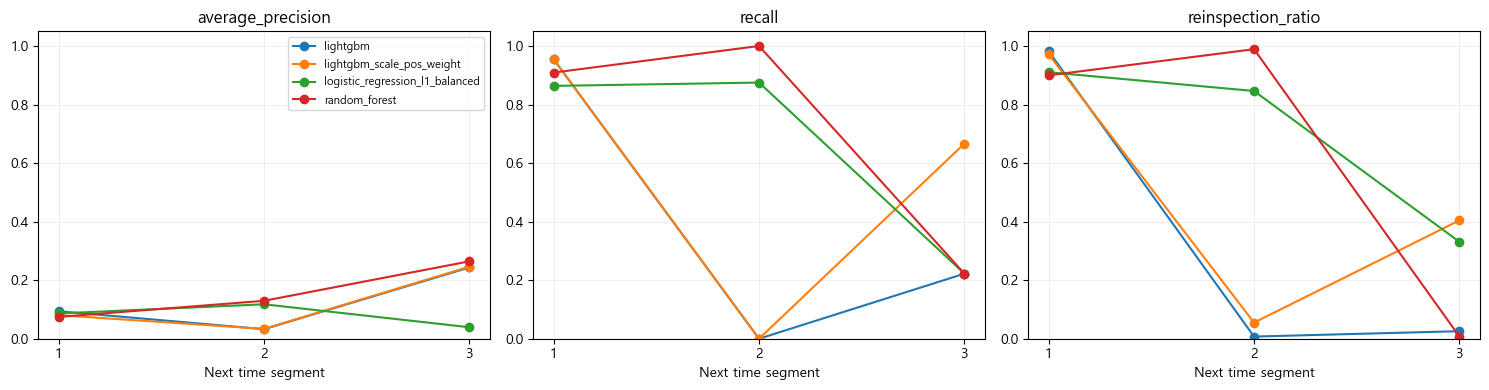

미생성 파일: logs\temporal_quality_filtered_20261006_final\policy_selection.csv


In [7]:
historical = read_log(sources['과거 시간 검증'])
if historical is not None:
    print('과거 실행: 기본 threshold 시간 검증 — 현재 정책 실행 결과가 아닙니다.')
    columns = ['experiment', 'threshold', 'average_precision', 'recall', 'precision',
               'true_positive', 'false_positive', 'false_negative', 'support']
    display(historical[columns])
if state.get('status') == 'completed' and state.get('time_validation_status') == 'completed':
    current_validation = read_log(POLICY_DIR / 'time_validation.csv')
    if current_validation is not None:
        print('선택한 실행 폴더의 시간 검증 결과')
        display(current_validation.drop(columns='quality_filter_log', errors='ignore'))
else:
    print('현재 정책 실행의 시간 검증 결과 없음:', state.get('time_validation_status', '기록 없음'))
folds = read_log(sources['시간순 내부 검증'])
if folds is not None:
    # 동일 점수의 threshold별 반복 행 중 시간순 OOF 방식만 그림에 사용한다.
    view = folds[folds['mode'] == 'temporal_oof'].copy()
    view['reinspection_ratio'] = (view.true_positive + view.false_positive) / view.support
    display(view[['outer_fold', 'model_name', 'threshold', 'average_precision', 'recall',
                  'reinspection_ratio', 'true_positive', 'false_positive', 'false_negative']])
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for model, rows in view.groupby('model_name'):
        rows = rows.sort_values('outer_fold')
        for ax, metric in zip(axes, ['average_precision', 'recall', 'reinspection_ratio']):
            ax.plot(rows.outer_fold, rows[metric], marker='o', label=model)
            ax.set(title=metric, xlabel='Next time segment', ylim=(0, 1.05))
            ax.set_xticks(sorted(view.outer_fold.unique()))
            ax.grid(alpha=0.2)
    axes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.show()
policy_history = read_log(sources['시간순 정책 결과'])
if policy_history is not None:
    print('시간순 정책 결과 — 파일에 기록된 정책이며 현재 config와 다를 수 있습니다.')
    display(policy_history)

## 6. 정상 전용 이상 탐지와 지도학습 비교

Isolation Forest와 PCA 복원오차는 정상만 학습합니다. 점수는 확률이 아니므로 모델 간 threshold 크기를 비교하지 않습니다. 아래 오류 건수는 각 과거 구간 내부 시간순 OOF의 **F1 최대 진단 후보**를 다음 시간 구간에 적용한 결과이며 정책 통과 성능이 아닙니다. 정책 미충족은 별도 표에 표시합니다.

,model_name,mode,model_family,ap_mean,ap_std,pooled_recall,pooled_precision,alarm_ratio,true_positive,false_positive,false_negative,true_negative
0,isolation_forest,temporal_oof,anomaly,0.108345,0.080476,0.205128,0.050633,0.191748,8,150,31,635
1,pca_reconstruction,temporal_oof,anomaly,0.092437,0.055385,0.589744,0.052874,0.527913,23,412,16,373


,dataset_id,outer_fold,model_name,mode,score_kind,min_recall,max_reinspection_ratio,selection_rule,on_infeasible,threshold,policy_status
0,secom,1,isolation_forest,temporal_oof,anomaly,0.9,0.2,min_reinspection,report_only,NaN,infeasible
1,secom,1,pca_reconstruction,temporal_oof,anomaly,0.9,0.2,min_reinspection,report_only,NaN,infeasible
2,secom,2,isolation_forest,temporal_oof,anomaly,0.9,0.2,min_reinspection,report_only,NaN,infeasible
3,secom,2,pca_reconstruction,temporal_oof,anomaly,0.9,0.2,min_reinspection,report_only,NaN,infeasible
4,secom,3,isolation_forest,temporal_oof,anomaly,0.9,0.2,min_reinspection,report_only,NaN,infeasible
5,secom,3,pca_reconstruction,temporal_oof,anomaly,0.9,0.2,min_reinspection,report_only,NaN,infeasible


,outer_fold,model_family,model_name,threshold,average_precision,recall,precision,true_positive,false_positive,false_negative
0,1,supervised,lightgbm,2.065200e-07,0.093858,0.954545,0.076642,21,253,1
1,1,supervised,lightgbm_scale_pos_weight,1.704510e-07,0.080448,0.954545,0.077491,21,250,1
2,1,supervised,random_forest,1.033333e-01,0.074466,0.909091,0.079681,20,231,2
3,1,supervised,logistic_regression_l1_balanced,3.858666e-04,0.086423,0.863636,0.074803,19,235,3
4,2,supervised,lightgbm,5.648696e-03,0.032643,0.000000,0.000000,0,2,8
5,2,supervised,lightgbm_scale_pos_weight,1.264474e-03,0.033573,0.000000,0.000000,0,15,8
6,2,supervised,random_forest,3.000000e-02,0.129526,1.000000,0.029630,8,262,0
7,2,supervised,logistic_regression_l1_balanced,4.062724e-04,0.117628,0.875000,0.030303,7,224,1
8,3,supervised,lightgbm,2.645452e-03,0.243548,0.222222,0.285714,2,5,7
9,3,supervised,lightgbm_scale_pos_weight,5.839464e-06,0.246151,0.666667,0.054545,6,104,3


,model_family,model_name,AP mean,AP std,pooled_recall,reinspection_ratio
4,supervised,logistic_regression_l1_balanced,0.081069,0.032259,0.717949,0.697816
1,anomaly,pca_reconstruction,0.092437,0.055385,0.589744,0.527913
0,anomaly,isolation_forest,0.108345,0.080476,0.205128,0.191748
3,supervised,lightgbm_scale_pos_weight,0.120057,0.091192,0.692308,0.480583
2,supervised,lightgbm,0.123349,0.088591,0.589744,0.343447
5,supervised,random_forest,0.156138,0.079800,0.769231,0.634709


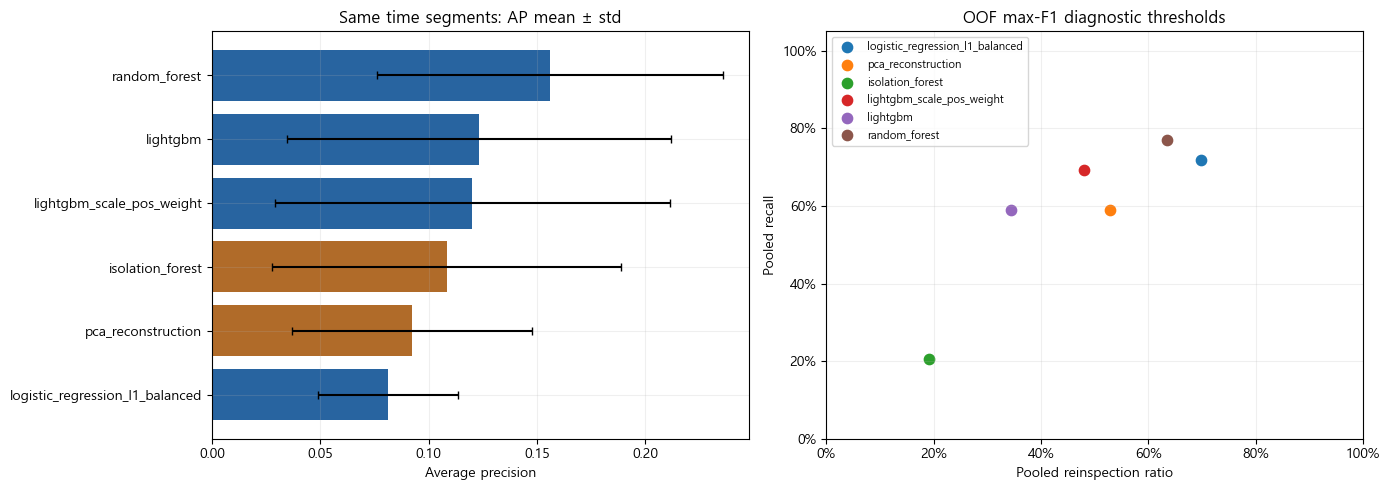

In [8]:
# ==========================================
# 같은 시간 구간의 지도학습·이상 탐지 결과를 비교
# - 실행 시 계약·학습 설정·시간 경계를 확인한 비교 파일을 사용
# - 합산 지표는 구간마다 다른 모델·문턱을 적용한 진단 결과
# ==========================================
anomaly_summary = read_log(sources['이상 탐지 요약'])
if anomaly_summary is not None:
    display(anomaly_summary)
anomaly_policy = read_log(sources['이상 탐지 정책'])
if anomaly_policy is not None:
    display(anomaly_policy)
comparison = read_log(ANOMALY_DIR / 'anomaly_compare.csv')
if comparison is not None:
    display(comparison[['outer_fold', 'model_family', 'model_name', 'threshold',
                        'average_precision', 'recall', 'precision',
                        'true_positive', 'false_positive', 'false_negative']])
    grouped = []
    for (family, name), rows in comparison.groupby(['model_family', 'model_name']):
        tp, fp, fn, tn = (int(rows[column].sum()) for column in
                         ['true_positive', 'false_positive', 'false_negative', 'true_negative'])
        grouped.append({'model_family': family, 'model_name': name,
            'AP mean': rows.average_precision.mean(), 'AP std': rows.average_precision.std(ddof=0),
            'pooled_recall': tp / (tp + fn), 'reinspection_ratio': (tp + fp) / (tp + fp + fn + tn)})
    chart = pd.DataFrame(grouped).sort_values('AP mean')
    display(chart)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#b06b29' if family == 'anomaly' else '#2864a0' for family in chart.model_family]
    axes[0].barh(chart.model_name, chart['AP mean'], xerr=chart['AP std'], color=colors, capsize=3)
    axes[0].set(title='Same time segments: AP mean ± std', xlabel='Average precision')
    for _, row in chart.iterrows():
        axes[1].scatter(row.reinspection_ratio, row.pooled_recall, label=row.model_name, s=55)
    axes[1].set(xlim=(0, 1), ylim=(0, 1.05), title='OOF max-F1 diagnostic thresholds',
                xlabel='Pooled reinspection ratio', ylabel='Pooled recall')
    axes[1].xaxis.set_major_formatter(ticker.PercentFormatter(1))
    axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(1))
    axes[1].legend(fontsize=8)
    for ax in axes:
        ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

## 7. 시간순 센서 축소와 선택 안정성

모든 분류기는 같은 LightGBM이고, 전체 특징·LightGBM 중요도·RF 중요도 선택만 바꿉니다. AP는 threshold와 무관하고 아래 Recall·재검사 비율은 **구간별 OOF F1 최대 진단**의 합산 값입니다. 선택 빈도는 겹치는 학습 구간의 참고값이며 센서의 인과관계나 최종 채택을 뜻하지 않습니다.

,outer_fold,model_name,mode,min_recall,max_reinspection_ratio,selection_rule,on_infeasible,policy_status,threshold
0,1,lightgbm_all,temporal_oof,0.9,0.2,min_reinspection,report_only,infeasible,NaN
1,1,lightgbm_top_50,temporal_oof,0.9,0.2,min_reinspection,report_only,infeasible,NaN
2,1,lightgbm_top_20,temporal_oof,0.9,0.2,min_reinspection,report_only,infeasible,NaN
3,1,lightgbm_rf_top_50,temporal_oof,0.9,0.2,min_reinspection,report_only,infeasible,NaN
4,1,lightgbm_rf_top_20,temporal_oof,0.9,0.2,min_reinspection,report_only,infeasible,NaN
5,2,lightgbm_all,temporal_oof,0.9,0.2,min_reinspection,report_only,infeasible,NaN
6,2,lightgbm_top_50,temporal_oof,0.9,0.2,min_reinspection,report_only,infeasible,NaN
7,2,lightgbm_top_20,temporal_oof,0.9,0.2,min_reinspection,report_only,infeasible,NaN
8,2,lightgbm_rf_top_50,temporal_oof,0.9,0.2,min_reinspection,report_only,infeasible,NaN
9,2,lightgbm_rf_top_20,temporal_oof,0.9,0.2,min_reinspection,report_only,infeasible,NaN


전체 Time Train의 연구용 후보 목록 — 최종 채택이 아닙니다.


,model_name,fit_role,train_samples,is_final,feature,selection_method,selection_rank,selection_importance,feature_space
494,lightgbm_top_20,candidate_full_train,1096,False,sensor_59,lightgbm_importance,1,293.0,raw_sensor
495,lightgbm_top_20,candidate_full_train,1096,False,sensor_64,lightgbm_importance,2,92.0,raw_sensor
496,lightgbm_top_20,candidate_full_train,1096,False,sensor_65,lightgbm_importance,3,60.0,raw_sensor
497,lightgbm_top_20,candidate_full_train,1096,False,sensor_33,lightgbm_importance,4,54.0,raw_sensor
498,lightgbm_top_20,candidate_full_train,1096,False,sensor_333,lightgbm_importance,5,53.0,raw_sensor
499,lightgbm_top_20,candidate_full_train,1096,False,sensor_460,lightgbm_importance,6,51.0,raw_sensor
500,lightgbm_top_20,candidate_full_train,1096,False,sensor_0,lightgbm_importance,7,46.0,raw_sensor
501,lightgbm_top_20,candidate_full_train,1096,False,sensor_341,lightgbm_importance,8,45.0,raw_sensor
502,lightgbm_top_20,candidate_full_train,1096,False,sensor_562,lightgbm_importance,9,38.0,raw_sensor
503,lightgbm_top_20,candidate_full_train,1096,False,sensor_131,lightgbm_importance,10,35.0,raw_sensor


,model_name,mode,ap_mean,ap_std,roc_auc_mean,recall_mean,pooled_recall,pooled_precision,alarm_ratio,true_positive,false_positive,false_negative,true_negative
3,lightgbm_top_50,temporal_oof,0.085735,0.047927,0.565114,0.584175,0.692308,0.068182,0.480583,27,369,12,416
7,lightgbm_rf_top_50,temporal_oof,0.100633,0.040318,0.538798,0.560606,0.589744,0.048832,0.571602,23,448,16,337
9,lightgbm_rf_top_20,temporal_oof,0.103825,0.063299,0.544042,0.449074,0.461538,0.053412,0.408981,18,319,21,466
5,lightgbm_top_20,temporal_oof,0.108106,0.050019,0.641559,0.298401,0.333333,0.065990,0.239078,13,184,26,601
1,lightgbm_all,temporal_oof,0.123349,0.088591,0.571047,0.392256,0.589744,0.081272,0.343447,23,260,16,525


,model_name,fit_role,feature,feature_space,selected_fit_count,mean_selection_rank,total_fit_count,selection_frequency
1281,lightgbm_top_20,outer_fit,sensor_0,raw_sensor,3,3.333333,3,1.000000
1282,lightgbm_top_20,outer_fit,sensor_333,raw_sensor,3,3.666667,3,1.000000
1283,lightgbm_top_20,outer_fit,sensor_341,raw_sensor,3,8.000000,3,1.000000
1284,lightgbm_top_20,outer_fit,sensor_115,raw_sensor,3,13.666667,3,1.000000
1285,lightgbm_top_20,outer_fit,sensor_59,raw_sensor,2,1.000000,3,0.666667
1286,lightgbm_top_20,outer_fit,sensor_64,raw_sensor,2,4.000000,3,0.666667
1287,lightgbm_top_20,outer_fit,sensor_122,raw_sensor,2,6.000000,3,0.666667
1288,lightgbm_top_20,outer_fit,sensor_390,raw_sensor,2,10.000000,3,0.666667
1289,lightgbm_top_20,outer_fit,sensor_65,raw_sensor,2,11.000000,3,0.666667
1290,lightgbm_top_20,outer_fit,sensor_460,raw_sensor,2,11.500000,3,0.666667


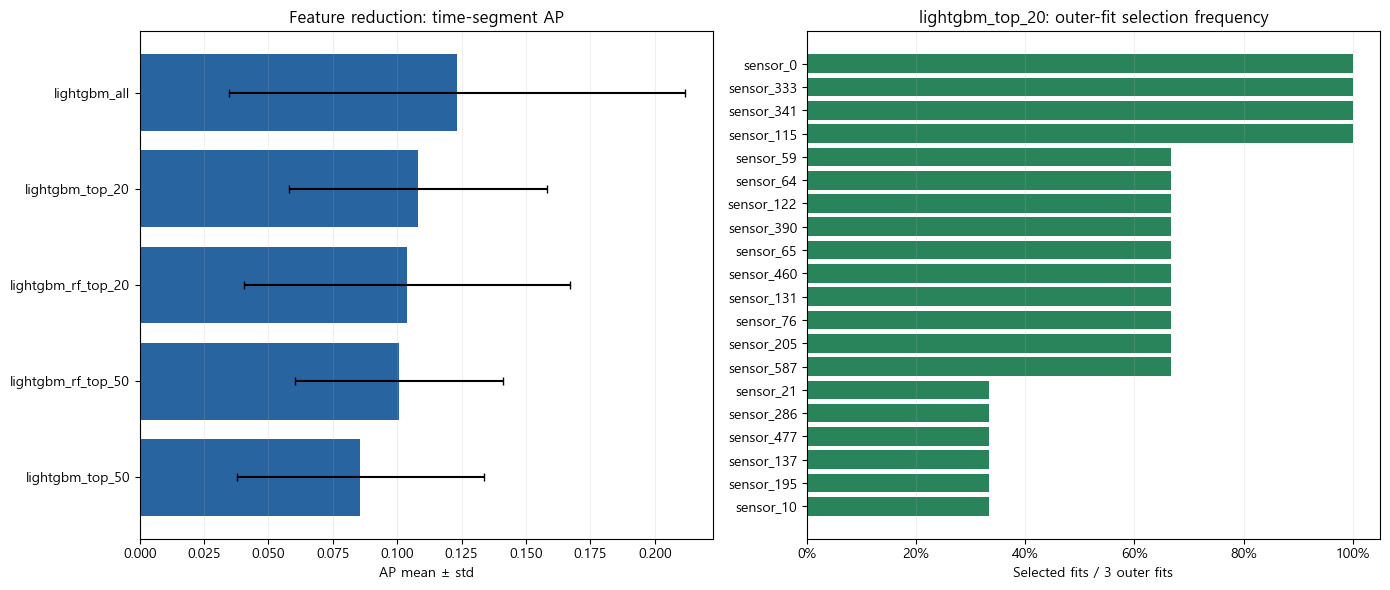

In [9]:
# ==========================================
# 센서 축소에 따른 AP·검출·검사 부담과 후보 센서 목록 확인
# - FEATURE_EXPERIMENT만 바꿔 선택 방법별 빈도를 확인
# - 전체 Train의 후보는 최종 센서 목록이 아님
# ==========================================
FEATURE_EXPERIMENT = 'lightgbm_top_20'
feature_summary = read_log(sources['시간순 센서 축소'])
frequency = read_log(FEATURE_DIR / 'feature_frequency.csv')
candidate_features = read_log(FEATURE_DIR / 'candidate_features.csv')
feature_policy = read_log(FEATURE_DIR / 'policy_selection.csv')
if feature_policy is not None:
    display(feature_policy)
if candidate_features is not None:
    print('전체 Time Train의 연구용 후보 목록 — 최종 채택이 아닙니다.')
    display(candidate_features[candidate_features.model_name == FEATURE_EXPERIMENT])
if feature_summary is not None and frequency is not None:
    performance = feature_summary[feature_summary['mode'] == 'temporal_oof'].sort_values('ap_mean')
    display(performance)
    stability = frequency[(frequency.model_name == FEATURE_EXPERIMENT) & (frequency.fit_role == 'outer_fit')].head(20)
    display(stability)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].barh(performance.model_name, performance.ap_mean, xerr=performance.ap_std, capsize=3, color='#2864a0')
    axes[0].set(title='Feature reduction: time-segment AP', xlabel='AP mean ± std')
    axes[1].barh(stability.feature[::-1], stability.selection_frequency[::-1], color='#29835b')
    axes[1].set(xlim=(0, 1.05), title=FEATURE_EXPERIMENT + ': outer-fit selection frequency',
                xlabel='Selected fits / 3 outer fits')
    axes[1].xaxis.set_major_formatter(ticker.PercentFormatter(1))
    for ax in axes:
        ax.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

## 8. V2 전체 센서 Feature Importance

아래 셀은 `logs/v2_sensor_importance/`의 진단 결과를 읽기만 합니다. 먼저 별도 명령으로 생성해야 하며 노트북에서는 모델을 학습하지 않습니다. 원본 전체 센서를 표시하고, 학습 제외 센서는 중요도 0이 아닌 빈 값과 제거 사유로 구분합니다. 전체 Train에서 학습한 설명용 gain 중요도이며 시간순 CV 중요도나 최종 센서 선정 결과가 아닙니다.

,sensor_count
status,
used,444
removed_constant,122
removed_high_missing,24


,feature,status,train_missing_ratio,gain_importance,importance_rank
0,sensor_405,used,0.004562,0.022637,1.0
1,sensor_59,used,0.004562,0.014005,2.0
2,sensor_138,used,0.005474,0.012737,3.0
3,sensor_430,used,0.001825,0.012736,4.0
4,sensor_524,used,0.000000,0.012485,5.0
5,sensor_247,used,0.303832,0.011491,6.0
6,sensor_446,used,0.000912,0.011404,7.0
7,sensor_473,used,0.004562,0.011337,8.0
8,sensor_78,used,0.000000,0.009706,9.0
9,sensor_267,used,0.004562,0.008845,10.0


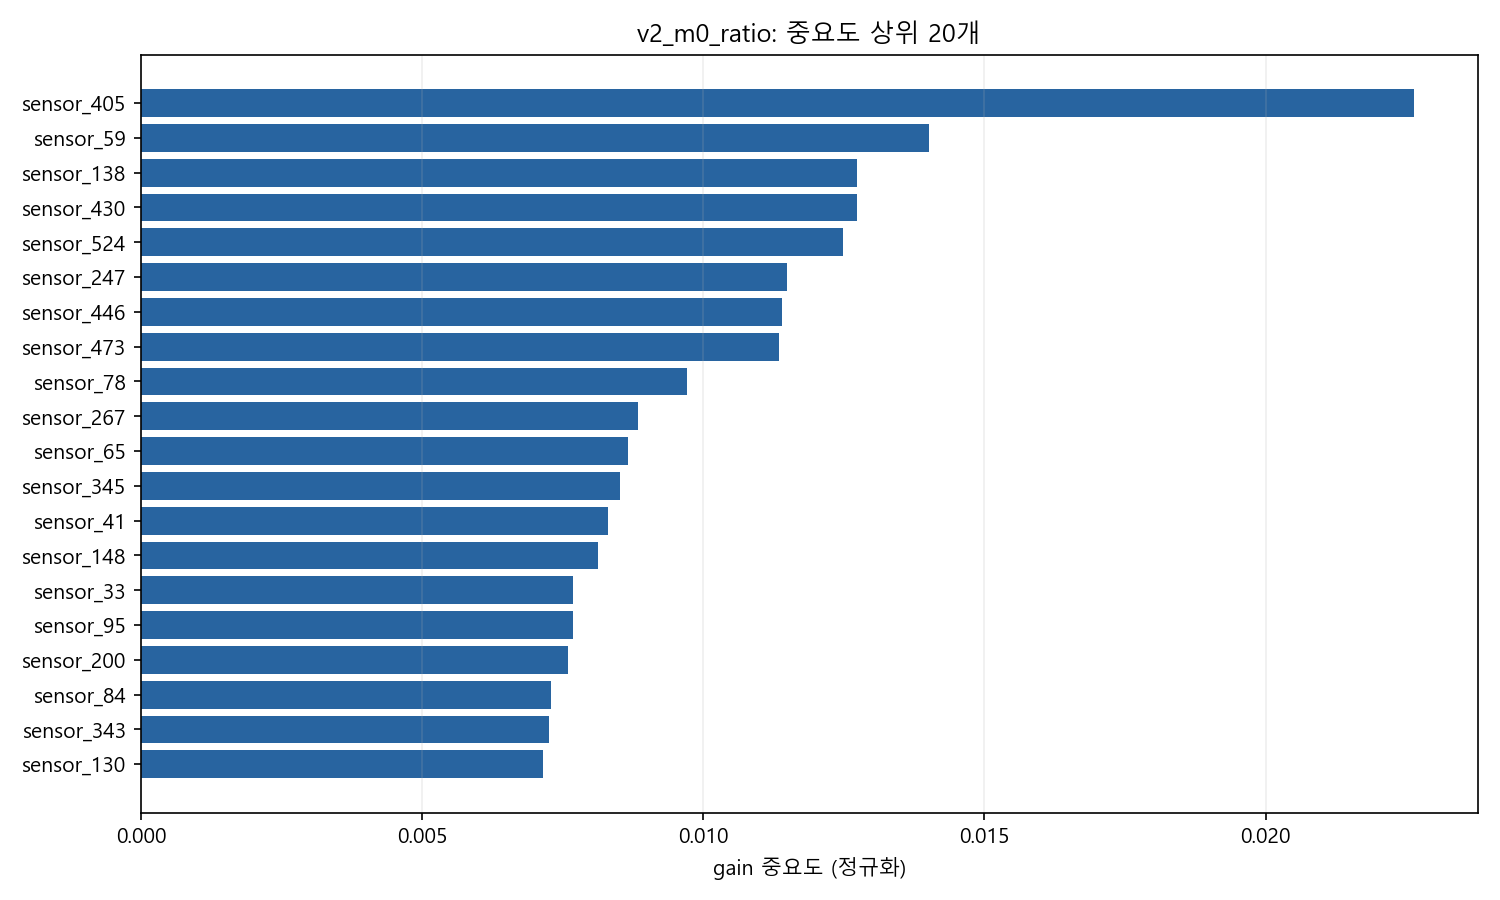

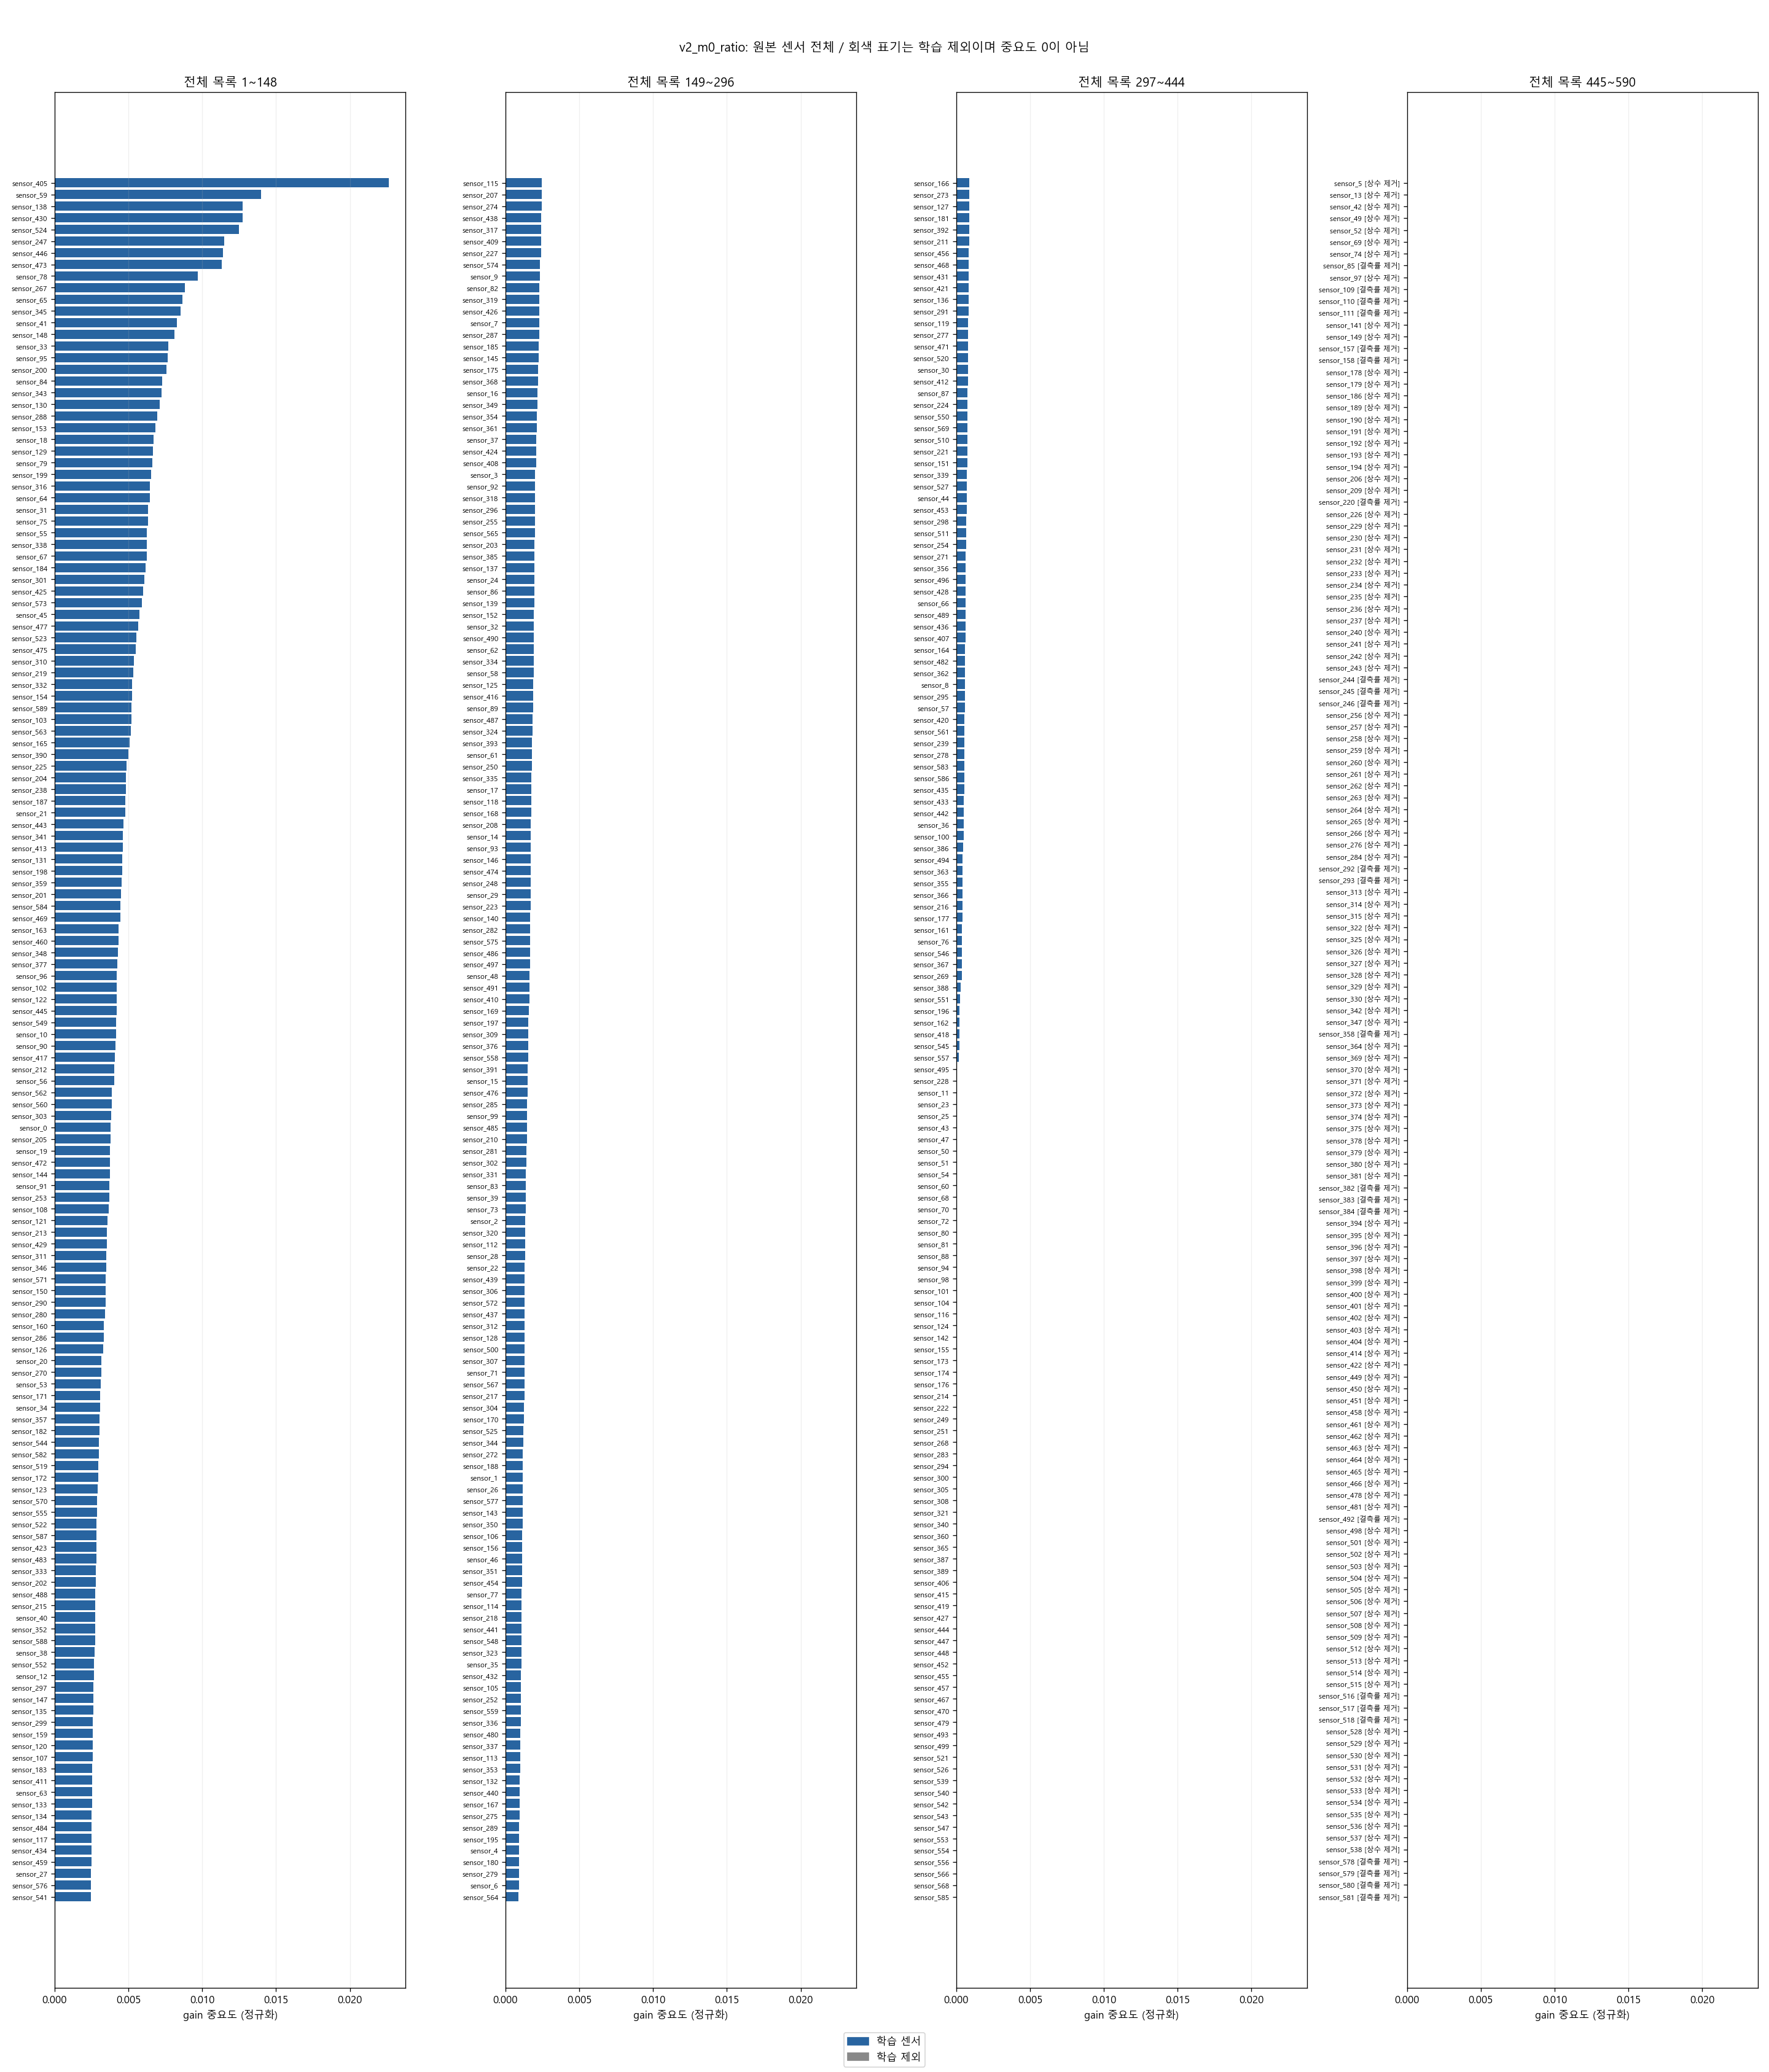

전체 그림의 센서명이 작으면 원본 PNG를 열어 확대하세요: d:\workspace\secom-waferguard\reports\figures\v2_sensor_importance


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

# 루트 또는 reports 폴더에서 실행해도 프로젝트 경로를 찾습니다.
importance_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/diagnostics/sensor_importance.py').is_file()), None)
if importance_root is None:
    raise RuntimeError('프로젝트 폴더에서 노트북을 실행하세요.')
importance_path = importance_root / 'logs/v2_sensor_importance/feature_importance.csv'
importance_figures = importance_root / 'reports/figures/v2_sensor_importance'
if not importance_path.exists():
    print('중요도 결과가 아직 없습니다. TIME_IMPROVEMENT_V2.md의 중요도 확인 명령을 먼저 실행하세요.')
else:
    importance_table = pd.read_csv(importance_path)
    display(importance_table.groupby('status', sort=False).size().rename('sensor_count').to_frame())
    # 원본 센서 전체 목록입니다. used의 0과 제거 센서의 NaN을 구분합니다.
    with pd.option_context('display.max_rows', None):
        display(importance_table)
    for importance_name in ('feature_importance_top20.png', 'feature_importance_all.png'):
        importance_image = importance_figures / importance_name
        if importance_image.exists():
            display(Image(filename=str(importance_image), width=1800 if 'all' in importance_name else 1000))
        else:
            print(f'그림 없음: {importance_image}')
    print('전체 그림의 센서명이 작으면 원본 PNG를 열어 확대하세요:', importance_figures)

## 해석과 다음 작업

- 조건 미충족은 프로그램 오류가 아니라 현재 OOF 후보가 목표를 동시에 달성하지 못했다는 결과입니다.
- 탐색용 시나리오는 config를 바꾸지 않고 위의 `RECALL_TARGETS`에서 비교할 수 있습니다. 선택한 정책으로 실제 시간 검증을 하려면 설정 변경 후 기존 실행기를 사용합니다.
- CSV·설정·소스가 변경되면 필요한 평가를 다시 실행한 뒤 이 노트북도 다시 실행합니다. 저장된 화면은 과거 실행 결과일 수 있습니다.
- 딥러닝 MLP·Autoencoder는 아직 별도 구현이 필요합니다. 이 노트북은 최종 Test를 읽지 않습니다.